## 01. Data Exploration & Preparation

In this notebook, I consolidate the raw data and passenger behaviors before diving into predictive modeling.

### Import Libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

### Load and Inspect Data

The dataset is from an airline passenger satisfaction survey sourced from the [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data) repository on Kaggle.

Below is a list of columns and their descriptions:

- `Gender`: Gender of the passengers (Female, Male)

- `Customer` Type: The customer type (Loyal customer, disloyal customer)
- `Age`: The actual age of the passengers
- `Type` of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- `Class`: Travel class in the plane of the passengers (Business, Eco, Eco Plus)
- `Flight distance`: The flight distance of this journey
- `Infligh wifi service`: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)
- `Departure/Arrival time convenient`: Satisfaction level of Departure/Arrival time convenient
- `Ease of Online booking`: Satisfaction level of online booking
- `Gate location`: Satisfaction level of Gate location
- `Food and drink`: Satisfaction level of Food and drink
- `Online boarding`: Satisfaction level of online boarding
- `Seat comfort`: Satisfaction level of Seat comfort
- `Inflight entertainment`: Satisfaction level of inflight entertainment
- `On-board service`: Satisfaction level of On-board service
- `Leg room service`: Satisfaction level of Leg room service
- `Baggage handling`: Satisfaction level of baggage handling
- `Check-in service`: Satisfaction level of Check-in service
- `Inflight service`: Satisfaction level of inflight service
- `Cleanliness`: Satisfaction level of Cleanliness
- `Departure Delay in Minutes`: Minutes delayed when departure
- `Arrival Delay in Minutes`: Minutes delayed when Arrival
- `Satisfaction`: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

In [27]:
# Load Data
train_df = pd.read_csv("../datasets/Airline Passanger Satisfaction/train.csv")
test_df = pd.read_csv("../datasets/Airline Passanger Satisfaction/test.csv")

train_df["type"] = "train"
test_df["type"] = "test"

df = pd.concat([train_df, test_df], ignore_index=True).drop("Unnamed: 0", axis=1).set_index("id")

display(df.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
id,,,,,,,,,,,,,,,,,,,,,
70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


The Kaggle repository is already split in `train` and `test` datasets. I decided to merge the datasets to allow for a holistic exploration of the data and consistent Feature Engineering across the entire population.

In [16]:
# Check Data Shape
df.shape

(129880, 24)

In [17]:
# Check Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 70172 to 34799
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880

In [18]:
# Check Null Values
df.isnull().sum() / df.shape[0] * 100

Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                          0.000000
Departure Delay in Minutes           0.000000
Arrival Delay in Minutes          

Missing data accounts for <0.3% of the dataset.

In [19]:
# Check Data Description
display(df.describe())

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


### Check Data Distribution

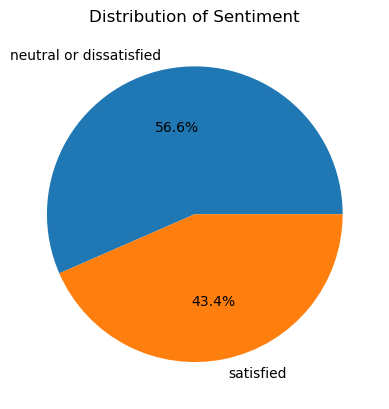

In [20]:
# Plot distribution of Sentiment
fig, ax = plt.subplots()
ax.pie(
    df["satisfaction"].value_counts(), 
    labels=df["satisfaction"].value_counts().index, 
    autopct="%1.1f%%"
)
ax.set_title("Distribution of Sentiment")
plt.show()

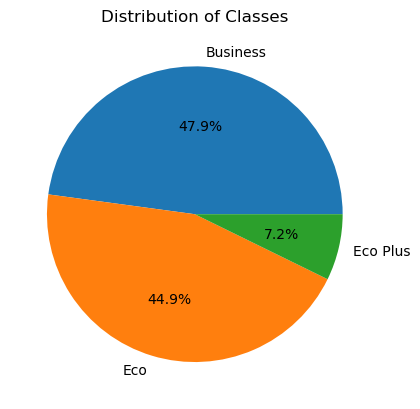

In [21]:
# Plot distribution of Classes
fig, ax = plt.subplots()
ax.pie(
    df['Class'].value_counts(), 
    labels=df['Class'].value_counts().index, 
    autopct="%1.1f%%"
)
ax.set_title("Distribution of Classes")
plt.show()

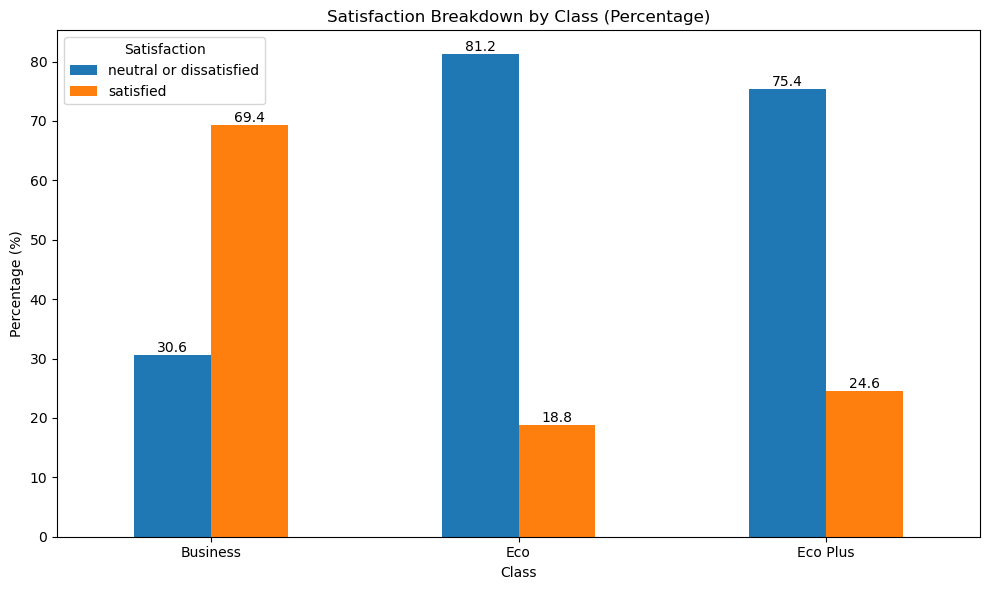

In [22]:
# Plot Satisfaction Breakdown by Class
satisfaction_counts = pd.crosstab(df['Class'], df['satisfaction'])
satisfaction_pct = (pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100).round(1)


fig, ax = plt.subplots(figsize=(10, 6))
satisfaction_pct.plot(kind='bar', ax=ax)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Satisfaction Breakdown by Class (Percentage)')
ax.set_xlabel('Class')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Satisfaction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

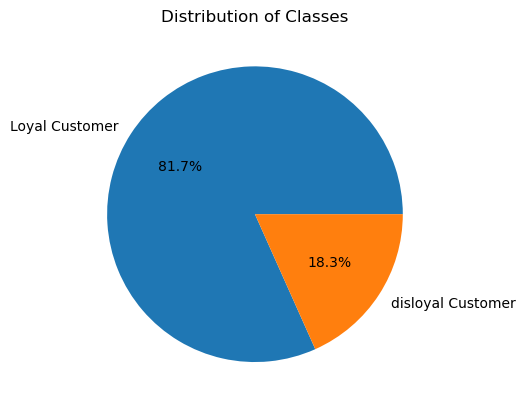

In [23]:
# Plot distribution of Customer Type
fig, ax = plt.subplots()
ax.pie(
    df['Customer Type'].value_counts(), 
    labels=df['Customer Type'].value_counts().index, 
    autopct="%1.1f%%"
)
ax.set_title("Distribution of Classes")
plt.show()

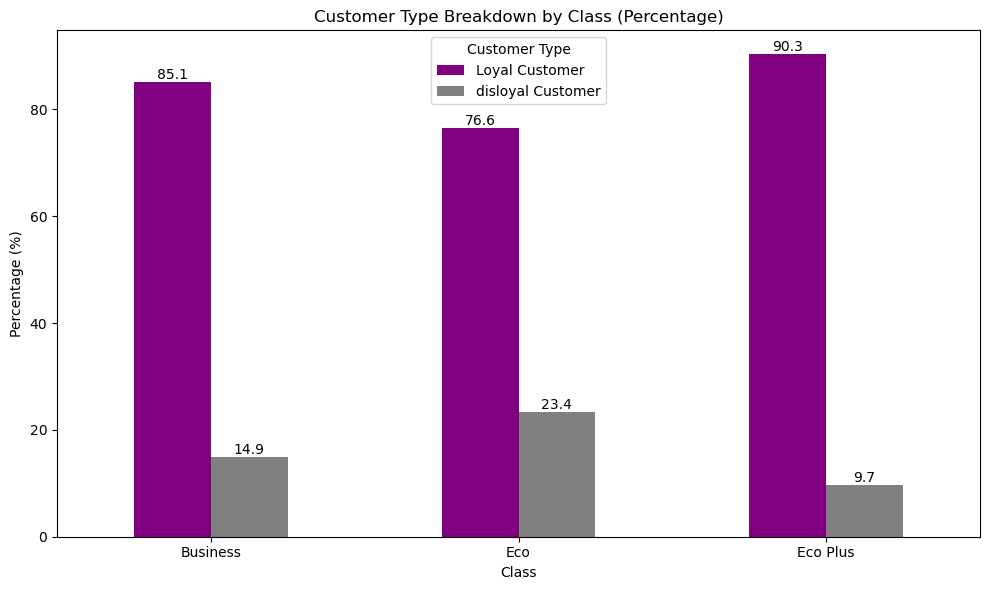

In [24]:
# Plot Loyalty Breakdown by Class
loyal_counts = pd.crosstab(df['Class'], df['Customer Type'])
loyal_pct = (pd.crosstab(df['Class'], df['Customer Type'], normalize='index') * 100).round(1)


fig, ax = plt.subplots(figsize=(10, 6))
loyal_pct.plot(kind='bar', ax=ax, color=['purple', 'grey'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Customer Type Breakdown by Class (Percentage)')
ax.set_xlabel('Class')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Customer Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Business Class passengers are significantly more satisfied (69.4%) compared to Economy (~18%). However, Business Class passengers show a *lower* loyalty rate (85.1%) compared to Economy Plus (90.3%).

High satisfaction scores are not translating into higher loyalty for premium travelers. Perphaps Business travelers demand more than just comfort to stay loyal. This finding drives the hypothesis for the [Notebook 02](02_baseline_model_discovery.ipynb): *What specific features drive satisfaction?*

### Preprocess Data

In [25]:
df_cleaned = df.copy()
df_cleaned.dropna(inplace=True)
df_cleaned.isnull().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
type                                 0
dtype: int64

Remove rows with missing values(`Arrival Delay`) "Delay" is a hard operational metric. Imputing it (e.g., filling with the mean) creates "fake" on-time flights that may confuse the model's ability to detect the impact of actual delays. The dataset remains large enough (>100k rows) to support robust modeling without these rows.

In [26]:
df_cleaned.to_csv("../datasets/processed/cleaned_data.csv", index=True)